In [1]:
import xarray as xr
from dask.distributed import LocalCluster
from dask import delayed
import icechunk as ic
import fsspec
from datetime import datetime
from virtualizarr import open_virtual_dataset
from obstore.store import from_url

from virtualizarr import open_virtual_dataset, open_virtual_mfdataset
from virtualizarr.parsers import HDFParser
from virtualizarr.registry import ObjectStoreRegistry

In [2]:
cluster = LocalCluster(dashboard_address="127.0.0.1:8786")

In [3]:
client = cluster.get_client()

In [4]:
def create_query(date, band='C01'):
    """
    Creates a query for listing GOES16 files stored in AWS bucket
    :param date: date to be queried. e.g datetime(2021, 10, 3, 12). Datetime python object
    :param band: Goes16 band to be queried e.g. C01
    :return: string with a
    """
    prefix = f'ABI-L1b-RadF/{date:%Y}/{date.timetuple().tm_yday:03d}/{date:%H}/OR_ABI-L1b-RadF-M6{band}_G19_s' \
             f'{date:%Y}{date.timetuple().tm_yday:03d}*'
    return prefix

def download_s3file(s3_path: str)-> str:
    return fsspec.open_local(
            f"simplecache::s3://{s3_path}",
            s3={"anon": True},
            filecache={"cache_storage": "."},
        )

In [5]:
fs = fsspec.filesystem("s3", anon=True)

In [6]:
dt = datetime(2025, 4, 2, 13, 10, 4)  # Match your original timestamp
query = create_query(dt, band="C13")
query

'ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s2025092*'

In [7]:
goes_files =  ['s3://' + f for f in
              # sorted(fs.glob(f"s3://noaa-goes19/ABI-L1b-RadF/2025/092/13/*"))
              sorted(fs.glob(f"s3://noaa-goes19/{query}"))
             ]

In [8]:
goes_files

['s3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921300198_e20250921309518_c20250921309563.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921310198_e20250921319518_c20250921319543.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921320198_e20250921329517_c20250921329546.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921330198_e20250921339517_c20250921339553.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921340198_e20250921349518_c20250921349556.nc',
 's3://noaa-goes19/ABI-L1b-RadF/2025/092/13/OR_ABI-L1b-RadF-M6C13_G19_s20250921350198_e20250921359517_c20250921359553.nc']

In [9]:
bucket = "s3://noaa-goes19/"
store = from_url(bucket, region="us-east-1", skip_signature=True)
registry = ObjectStoreRegistry({bucket: store})

In [10]:
parser = HDFParser()

In [11]:
goes_vds = [
    delayed(open_virtual_dataset)(
        url, 
        parser=parser,
        registry=registry
    )
    for url in goes_files
]


In [12]:
import dask
vds_ls = dask.compute(*goes_vds)

/media/alfonso/drive/Alfonso/python/goes-virt/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/media/alfonso/drive/Alfonso/python/goes-virt/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/media/alfonso/drive/Alfonso/python/goes-virt/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)
/media/alfonso/drive/Alfonso/python/goes-virt/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: 

In [13]:
ds_vir = xr.concat(
    vds_ls,
    dim="time",
    coords="minimal",
    compat="override",
    combine_attrs="override",
)

In [15]:
storage = ic.local_filesystem_storage("./goes19")

  2025-12-04T17:29:40.920524Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:80



In [16]:
config = ic.RepositoryConfig.default()

In [17]:
config.set_virtual_chunk_container(
  ic.VirtualChunkContainer("s3://noaa-goes19/", ic.s3_store(region="us-east-1"))
)

In [18]:
# credentials = ic.s3_anonymous_credentials()
credentials = ic.containers_credentials(
  {"s3://noaa-goes19/": ic.s3_credentials(anonymous=True)}
)

In [19]:
repo = ic.Repository.open_or_create(storage, config, credentials)

In [20]:
session = repo.writable_session("main")

In [21]:
ds_vir.virtualize.to_icechunk(session.store)

In [25]:
session.commit("Added GOES-19 virtual references")

'WGQW66R4JEBKRMBF2YPG'

In [26]:
read_session = repo.readonly_session(branch="main")

In [28]:
ds = xr.open_zarr(
    read_session.store, 
    consolidated=False, 
    zarr_format=3)
ds

<xarray.Dataset> Size: 2GB
Dimensions:                                           (time: 6, y: 5424,
                                                       x: 5424,
                                                       number_of_harmonization_coefficients: 3,
                                                       num_star_looks: 24,
                                                       number_of_time_bounds: 2,
                                                       number_of_image_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float64 43kB 0.1518...
  * x                                                 (x) float64 43kB -0.151...
  * number_of_harmonization_coefficients              (number_of_harmonization_coefficients) float32 12B ...
  * num_star_looks                                    (num_star_looks) float32 96B ...
    band_id                                           (band) int8 1B dask.array<chunksize=(1,), meta=np.ndarray>
    band_wavelength_star_look                         (num_star_looks) float32 96B dask.array<chunksize=(24,), meta=np.ndarray>
    band_wavelength                                   (band) float32 4B dask.array<chunksize=(1,), meta=np.ndarray>
    t                                                 datetime64[ns] 8B ...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B dask.array<chunksize=(24,), meta=np.ndarray>
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: time, number_of_time_bounds,
                                number_of_image_bounds, band
Data variables: (12/39)
    DQF                                               (time, y, x) float32 706MB dask.array<chunksize=(1, 226, 226), meta=np.ndarray>
    Rad                                               (time, y, x) float64 1GB dask.array<chunksize=(1, 226, 226), meta=np.ndarray>
    a_h_NRTH                                          (time, number_of_harmonization_coefficients) float32 72B dask.array<chunksize=(1, 3), meta=np.ndarray>
    algorithm_dynamic_input_data_container            (time) int32 24B dask.array<chunksize=(1,), meta=np.ndarray>
    algorithm_product_version_container               (time) int32 24B dask.array<chunksize=(1,), meta=np.ndarray>
    b_h_NRTH                                          (time, number_of_harmonization_coefficients) float32 72B dask.array<chunksize=(1, 3), meta=np.ndarray>
    ...                                                ...
    undersaturated_pixel_count                        (time) float64 48B dask.array<chunksize=(1,), meta=np.ndarray>
    time_bounds                                       (time, number_of_time_bounds) datetime64[ns] 96B dask.array<chunksize=(1, 2), meta=np.ndarray>
    valid_pixel_count                                 (time) float64 48B dask.array<chunksize=(1,), meta=np.ndarray>
    x_image_bounds                                    (time, number_of_image_bounds) float32 48B dask.array<chunksize=(1, 2), meta=np.ndarray>
    y_image_bounds                                    (time, number_of_image_bounds) float32 48B dask.array<chunksize=(1, 2), meta=np.ndarray>
    yaw_flip_flag                                     (time) float32 24B dask.array<chunksize=(1,), meta=np.ndarray>
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2025-04-02T13:09:56.3Z
    time_coverage_start:       2025-04-02T13:00:19.8Z
    time_coverage_end:         2025-04-02

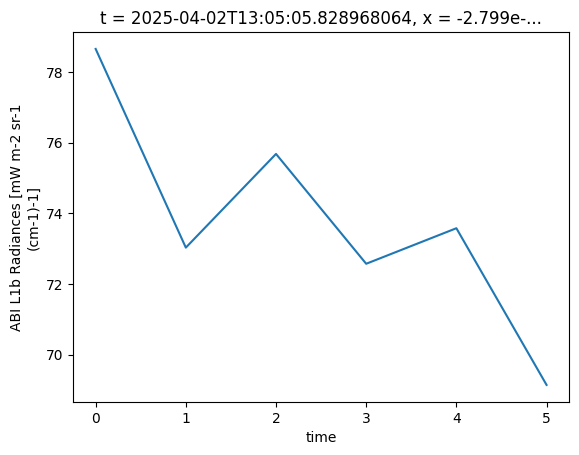

In [34]:
ds.Rad.sel(x=0, y=0,method="nearest").plot()

In [33]:
ds.x

<xarray.DataArray 'x' (x: 5424)> Size: 43kB
array([-0.151844, -0.151788, -0.151732, ...,  0.151732,  0.151788,  0.151844],
      shape=(5424,))
Coordinates:
  * x        (x) float64 43kB -0.1518 -0.1518 -0.1517 ... 0.1517 0.1518 0.1518
    t        datetime64[ns] 8B ...
    y_image  float32 4B ...
    x_image  float32 4B ...
Attributes:
    units:          rad
    axis:           X
    long_name:      GOES fixed grid projection x-coordinate
    standard_name:  projection_x_coordinate